In [1]:
import os
import re
import sys
import glob
import toml
import shutil
import textwrap
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from astropy.io import fits
from importlib import reload
from astropy.table import Table
from scipy.interpolate import interp1d
from joebvp import cfg, utils, VPmeasure

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Gill Sans"]

read_sets: Using set file -- 
  /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linetools/lists/sets/llist_v1.3.ascii
Loading abundances from Asplund2009
Abundances are relative by number on a logarithmic scale with H=12
linetools.lists.parse: Reading linelist --- 
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linetools/data/lines/morton03_table2.fits.gz
linetools.lists.parse: Reading linelist --- 
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linetools/data/lines/verner96_tab1.fits.gz
joebvp.makevoigt: No local joebvp_cfg.py found, using default cfg.py file from joebvp.
joebvp.VPmeasure: No local joebvp_cfg.py found, using default cfg.py file from joebvp.
Loading abundances from Asplund2009
Abundances are relative by number on a logarithmic scale with H=12
linetools.lists.parse: Reading linelist --- 
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-package

In [2]:
target_directory = Path().resolve()
spectra_directories = sorted([d for d in os.listdir(target_directory) if d.startswith("G") or d.startswith("E")])
galaxy = target_directory.parts[target_directory.parts.index('float-for-morrow') + 1]
region = target_directory.parts[target_directory.parts.index("float-for-morrow") + 2]
target = target_directory.name
print(spectra_directories)
print(galaxy)
print(region)

['E140M_1425_0.2x0.2_2215.200_16098', 'E140M_1425_0.2x0.2_2567.200_16098', 'E140M_1425_0.2x0.2_2700.000_7437']
SMC
SMC N66A


In [3]:
def parse_directory(dirname):

    Target = target_directory.name

    parts = dirname.split("_")

    Grating = parts[0]
    Cenwave = int(parts[1])
    T_exp = str(parts[3])
    PID = int(parts[4])

    if Grating.startswith("G"):
        
        Instrument = "COS"
        LP = parts[2]

        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": LP, 
            "Aperture": None, 
            "T_exp": T_exp, 
            "PID": PID, 
        }
        
    else:
        
        Instrument = "STIS"
        Aperture = parts[2]
        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": None, 
            "Aperture": Aperture, 
            "T_exp": T_exp, 
            "PID": PID, 
        }

records = [parse_directory(d) for d in spectra_directories]
df = pd.DataFrame.from_records(records)
display(df)

,Target,Instrument,Grating,Cenwave,LP,Aperture,T_exp,PID
0,Cl* NGC 346 W 3,STIS,E140M,1425,None,0.2x0.2,2215.200,16098
1,Cl* NGC 346 W 3,STIS,E140M,1425,None,0.2x0.2,2567.200,16098
2,Cl* NGC 346 W 3,STIS,E140M,1425,None,0.2x0.2,2700.000,7437


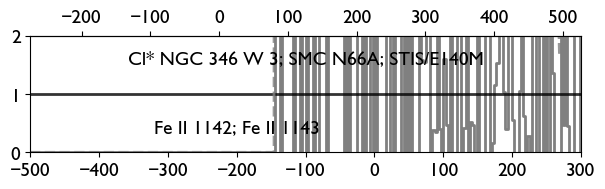

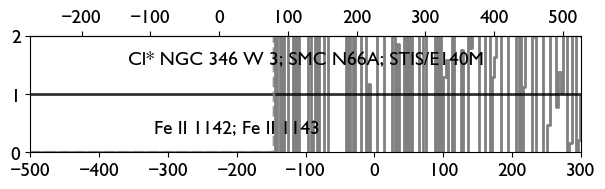

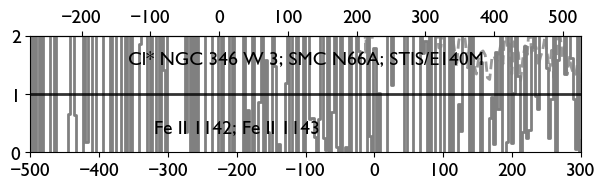

In [4]:
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))

        if not cont_matches or not fitinsp_matches:
            continue 

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
        w = w1[mask]
        f1n = f1n[mask]
        e1n = e1n[mask]
        f2n = f2n[mask]
        e2n = e2n[mask]

        fe_1142 = 1142.3656
        fe_1143 = 1143.2260
        c_kms = 299792.458
        
        v_1142 = c_kms * (w / fe_1142 - 1.0)
        v_1143 = c_kms * (w / fe_1143 - 1.0)
        
        def v1143_to_v1142(v_in):
            w_in = fe_1143 * (1.0 + v_in / c_kms)
            return c_kms * (w_in / fe_1142 - 1.0)
        
        def v1142_to_v1143(v1142_in):
            w_in = fe_1142 * (1.0 + v1142_in / c_kms)
            return c_kms * (w_in / fe_1143 - 1.0)

        y0, y1 = 0.5, 1.5
        
        fig, ax = plt.subplots(figsize = (6, 2))

        ax.plot(v_1143, f2n, drawstyle = "steps-mid", lw = 2.0, label = "continuumfit: FLUX/CONTINUUM", color = '0.5')
        ax.plot(v_1143, f1n, lw = 2.0, alpha = 0.8, label = "FitInspection: FLUX/CONTINUUM", color = '0')
        ax.plot(v_1143, e2n, color =" 0.5", ls = "--", lw = 2.0, alpha = 0.8, label = "continuumfit 1σ error")
        
        ax.text(-200, 0.4, "Fe II 1142; Fe II 1143", fontsize = 14, ha = "center", va = "center")
        ax.text(-100, 1.6, f"{target}; {region}; {instrument}/{grating}", ha = "center", va = "center", fontsize = 14)
        
        ax.tick_params(axis = "both", which = "major", labelsize = 14)
        ax.set_xlim(-500, 300)
        ax.set_ylim(0, 2)
        
        secax = ax.secondary_xaxis('top', functions=(v1143_to_v1142, v1142_to_v1143))
        secax.tick_params(axis = "x", which = "major", labelsize = 14)
        
        fig.tight_layout()
        outfile = subdir_path / "Fe II 1142 1143.png"
        fig.savefig(outfile, dpi = 300, bbox_inches = "tight")
        plt.show()
        plt.close(fig)

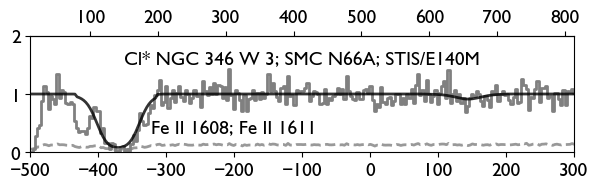

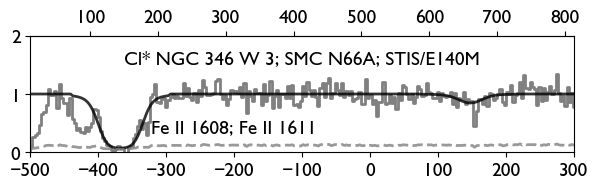

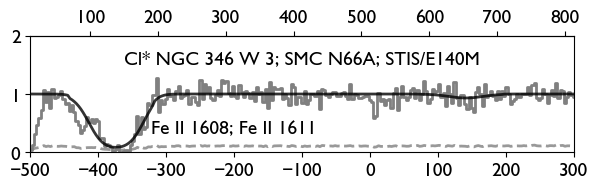

In [5]:
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))

        if not cont_matches or not fitinsp_matches:
            continue 

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
        w = w1[mask]
        f1n = f1n[mask]
        e1n = e1n[mask]
        f2n = f2n[mask]
        e2n = e2n[mask]

        fe_1142 = 1608.451
        fe_1143 = 1611.201
        c_kms = 299792.458
        
        v_1142 = c_kms * (w / fe_1142 - 1.0)
        v_1143 = c_kms * (w / fe_1143 - 1.0)
        
        def v1143_to_v1142(v_in):
            w_in = fe_1143 * (1.0 + v_in / c_kms)
            return c_kms * (w_in / fe_1142 - 1.0)
        
        def v1142_to_v1143(v1142_in):
            w_in = fe_1142 * (1.0 + v1142_in / c_kms)
            return c_kms * (w_in / fe_1143 - 1.0)

        y0, y1 = 0.5, 1.5
        
        fig, ax = plt.subplots(figsize = (6, 2))

        ax.plot(v_1143, f2n, drawstyle = "steps-mid", lw = 2.0, label = "continuumfit: FLUX/CONTINUUM", color = '0.5')
        ax.plot(v_1143, f1n, lw = 2.0, alpha = 0.8, label = "FitInspection: FLUX/CONTINUUM", color = '0')
        ax.plot(v_1143, e2n, color =" 0.5", ls = "--", lw = 2.0, alpha = 0.8, label = "continuumfit 1σ error")
        
        ax.text(-200, 0.4, "Fe II 1608; Fe II 1611", fontsize = 14, ha = "center", va = "center")
        ax.text(-100, 1.6, f"{target}; {region}; {instrument}/{grating}", ha = "center", va = "center", fontsize = 14)
        
        ax.tick_params(axis = "both", which = "major", labelsize = 14)
        ax.set_xlim(-500, 300)
        ax.set_ylim(0, 2)
        
        secax = ax.secondary_xaxis('top', functions=(v1143_to_v1142, v1142_to_v1143))
        secax.tick_params(axis = "x", which = "major", labelsize = 14)
        
        fig.tight_layout()
        outfile = subdir_path / "Fe II 1608 1611.png"
        fig.savefig(outfile, dpi = 300, bbox_inches = "tight")
        plt.show()
        plt.close(fig)

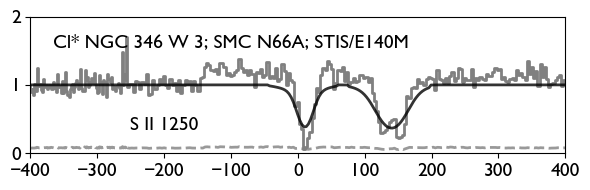

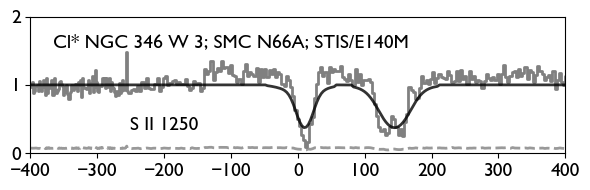

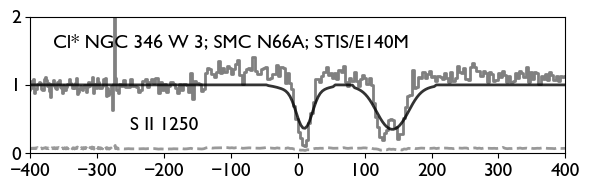

In [6]:
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))

        if not cont_matches or not fitinsp_matches:
            continue 

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
        w   = w1[mask]
        f1n = f1n[mask]
        e1n = e1n[mask]
        f2n = f2n[mask]
        e2n = e2n[mask]

        lam0 = 1250.5840
        c_kms = 299792.458
        
        v_center = 260.0
        dv = 800.0

        v = c_kms * (w / lam0 - 1.0)
        
        plt.figure(figsize = (6, 2))
        plt.plot(v, f2n, drawstyle = "steps-mid", lw = 2.0, label = "continuumfit: FLUX/CONTINUUM", color = '0.5')
        plt.plot(v, f1n, lw = 2.0, alpha = 0.8, label = "FitInspection: FLUX/CONTINUUM", color = '0')

        step = max(1, len(v) // 8000)
        plt.plot(v, e2n, color = "0.5", ls = "--", lw = 2.0, alpha = 0.8, label = "continuumfit 1σ error",)

        plt.text(-200, 0.4, "S II 1250", fontsize = 14, ha = "center", va = "center")

        plt.text(-100, 1.6, f"{target}; {region}; {instrument}/{grating}", ha = "center", va = "center", fontsize = 14)

        plt.tick_params(axis = "both", which = "major", labelsize = 14)
        plt.xlim(-400, 400)
        plt.ylim(0, 2)
        plt.tight_layout()
        outfile = subdir_path / "S II 1250.png"
        plt.savefig(outfile, dpi = 300, bbox_inches = "tight")
        plt.show()
        plt.close()

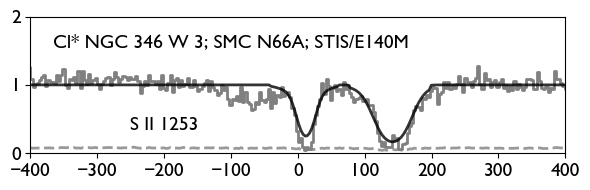

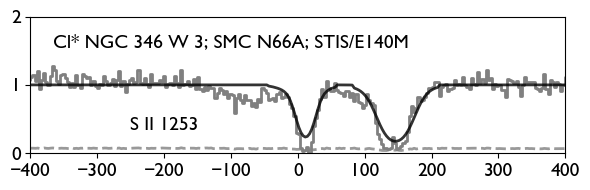

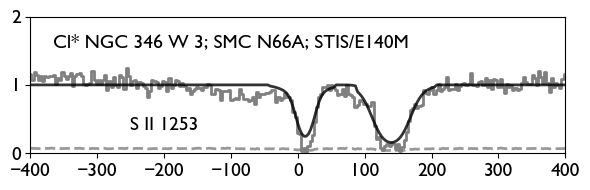

In [7]:
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))

        if not cont_matches or not fitinsp_matches:
            continue 

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
        w   = w1[mask]
        f1n = f1n[mask]
        e1n = e1n[mask]
        f2n = f2n[mask]
        e2n = e2n[mask]

        lam0 = 1253.805
        c_kms = 299792.458
        
        v_center = 260.0
        dv = 800.0

        v = c_kms * (w / lam0 - 1.0)
        
        plt.figure(figsize = (6, 2))
        plt.plot(v, f2n, drawstyle = "steps-mid", lw = 2.0, label = "continuumfit: FLUX/CONTINUUM", color = '0.5')
        plt.plot(v, f1n, lw = 2.0, alpha = 0.8, label = "FitInspection: FLUX/CONTINUUM", color = '0')

        step = max(1, len(v) // 8000)
        plt.plot(v, e2n, color = "0.5", ls = "--", lw = 2.0, alpha = 0.8, label = "continuumfit 1σ error",)

        plt.text(-200, 0.4, "S II 1253", fontsize = 14, ha = "center", va = "center")

        plt.text(-100, 1.6, f"{target}; {region}; {instrument}/{grating}", ha = "center", va = "center", fontsize = 14)

        plt.tick_params(axis = "both", which = "major", labelsize = 14)
        plt.xlim(-400, 400)
        plt.ylim(0, 2)
        plt.tight_layout()
        outfile = subdir_path / "S II 1253.png"
        plt.savefig(outfile, dpi = 300, bbox_inches = "tight")
        plt.show()
        plt.close()

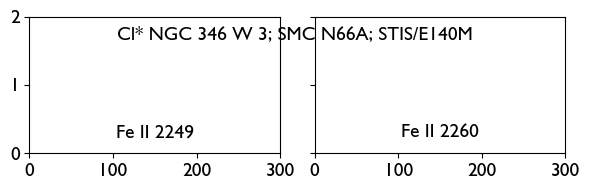

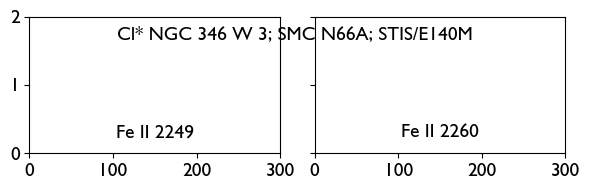

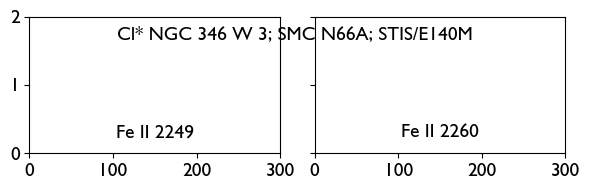

In [8]:
LINES = [
    ("Fe II 2249", 2249.877),
    ("Fe II 2260", 2260.780),
]

for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        if not cont_matches or not fitinsp_matches:
            continue

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n) & np.isfinite(e2n)
        w = w1[mask]
        f1n_m = f1n[mask]
        f2n_m = f2n[mask]
        e2n_m = e2n[mask]

        c_kms = 299792.458

        fig, axes = plt.subplots(1, 2, figsize = (6, 2), sharey = True)

        for ax, (label, lam0) in zip(axes, LINES):
            v = c_kms * (w / lam0 - 1.0)

            ax.plot(v, f2n_m, drawstyle = "steps-mid", lw = 2.0, color = "0.5")
            ax.plot(v, f1n_m, lw = 2.0, alpha = 0.8, color = "0")
            ax.plot(v, e2n_m, color = "0.5", ls = "--", lw = 2.0, alpha = 0.8)

            ax.set_xlim(0, 300)
            ax.set_ylim(0, 2)
            ax.tick_params(axis = "both", which = "major", labelsize = 14)
            ax.text(0.5, 0.15, label, transform = ax.transAxes, fontsize = 14, ha = "center", va = "center")

        fig.text(0.5, 0.8, f"{target}; {region}; {instrument}/{grating}", ha = "center", va = "center", fontsize = 14)

        fig.tight_layout()

        outfile = subdir_path / "FeII 2249 2260.png"
        fig.savefig(outfile, dpi = 300, bbox_inches = "tight")
        plt.show()
        plt.close(fig)

In [9]:
# END